# Análise Exploratória dos dados

In [44]:
%%capture
!pip install xgboost catboost scikit-learn matplotlib seaborn pandas numpy

In [45]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GroupKFold
from sklearn.feature_selection import RFECV
from catboost import CatBoostRegressor
from sklearn.cluster import HDBSCAN
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from google.colab import drive
import os, unicodedata, re
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [46]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto'
file_path = os.path.join(base_dir, 'BD_filerCalcario_versao_1.xlsx')
file = pd.ExcelFile(file_path)
base_dir = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
print(file.sheet_names)
scaler = StandardScaler()
encoder = LabelEncoder()
clusterer = HDBSCAN(min_cluster_size=2, min_samples=2)

['BD_ML_Resis', 'BD_ML_Slump', 'Dicionario_Variaveis']


In [48]:
df_resistencia = file.parse('BD_ML_Resis')
df_resistencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Autores/ano                  599 non-null    object 
 1   ID_Mistura                   599 non-null    object 
 2   Tipo_Cimento_Classe          599 non-null    object 
 3   Massa_Esp_Cimento_g_cm3      462 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg  414 non-null    float64
 5   Massa_Esp_Filer_g_cm3        358 non-null    float64
 6   Massa_Esp_Areia_g_cm3        262 non-null    float64
 7   Massa_Esp_Brita_g_cm3        273 non-null    float64
 8   Cimento_kg_m3                599 non-null    float64
 9   Filer_Calcario_kg_m3         599 non-null    float64
 10  Agua_kg_m3                   599 non-null    float64
 11  Agregado_Miudo_Total_kg_m3   599 non-null    float64
 12  Agregado_Graudo_Total_kg_m3  599 non-null    float64
 13  Superplastificante_k

In [49]:
df_resistencia.Tipo_Cimento_Classe.sort_values(ascending=False).value_counts()

,count
Tipo_Cimento_Classe,
"CEM I 42,5 N",175
ASTM C 150 Type I,75
CP-V ARI,51
Type I OPC,50
"CEM I 42,5 R",41
OPC,40
Type I Portland,24
"P,I 42,5 (CEM I)",21
OPC (ASTM C150),21


In [50]:
autores = df_resistencia['Autores/ano'].unique()

for autor in autores:
    df_autor = df_resistencia[df_resistencia['Autores/ano'] == autor]
    print(f"{autor}, Número de amostras: {len(df_autor)} | {df_autor.shape[0]/len(df_resistencia)*100:.2f}%")

Dos Santos et al, 2024, Número de amostras: 15 | 2.50%
Guemmadi et al, 2009, Número de amostras: 26 | 4.34%
Meddah et al 2014, Número de amostras: 175 | 29.22%
A Morzouki 2016, Número de amostras: 35 | 5.84%
Bentz et al, 2015, Número de amostras: 11 | 1.84%
Feltrin 2018, Número de amostras: 36 | 6.01%
Gyu Don Moon 2017, Número de amostras: 24 | 4.01%
Hieu T Cam 2010, Número de amostras: 12 | 2.00%
Md Jahidul Islam 2025, Número de amostras: 15 | 2.50%
Diab et al, (2016), Número de amostras: 24 | 4.01%
Mohammed e Al-Numan (2024), Número de amostras: 15 | 2.50%
Leeuwen et al, (2016), Número de amostras: 50 | 8.35%
Ramezanianpour et al. (2009), Número de amostras: 75 | 12.52%
Bayan 2018, Número de amostras: 25 | 4.17%
Bonavetti et al. (2000)., Número de amostras: 9 | 1.50%
Tsivilis et al. (2003), Número de amostras: 10 | 1.67%
Sun e Chen 2018, Número de amostras: 21 | 3.51%
Abdul-Ghani et al, 2019, Número de amostras: 21 | 3.51%


In [51]:
df_resistencia['cod_classe'] = encoder.fit_transform(df_resistencia['Tipo_Cimento_Classe'])
df_resistencia['cod_classe'].value_counts()

,count
cod_classe,
6,175
0,75
10,51
17,50
7,41
13,40
18,24
14,21
15,21


/tmp/ipykernel_936/1906372192.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


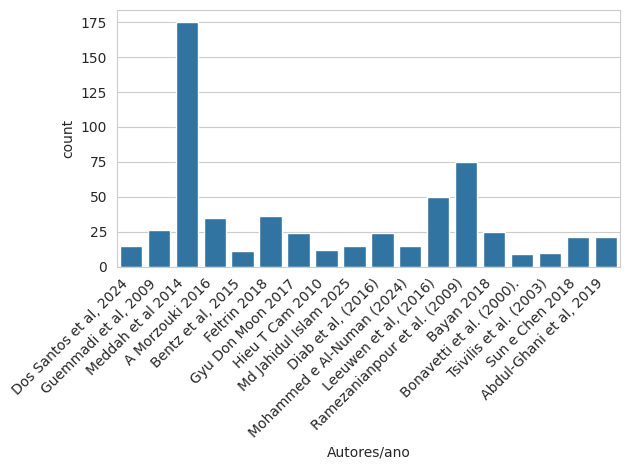

In [52]:
ax = sns.countplot(x='Autores/ano', data=df_resistencia)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

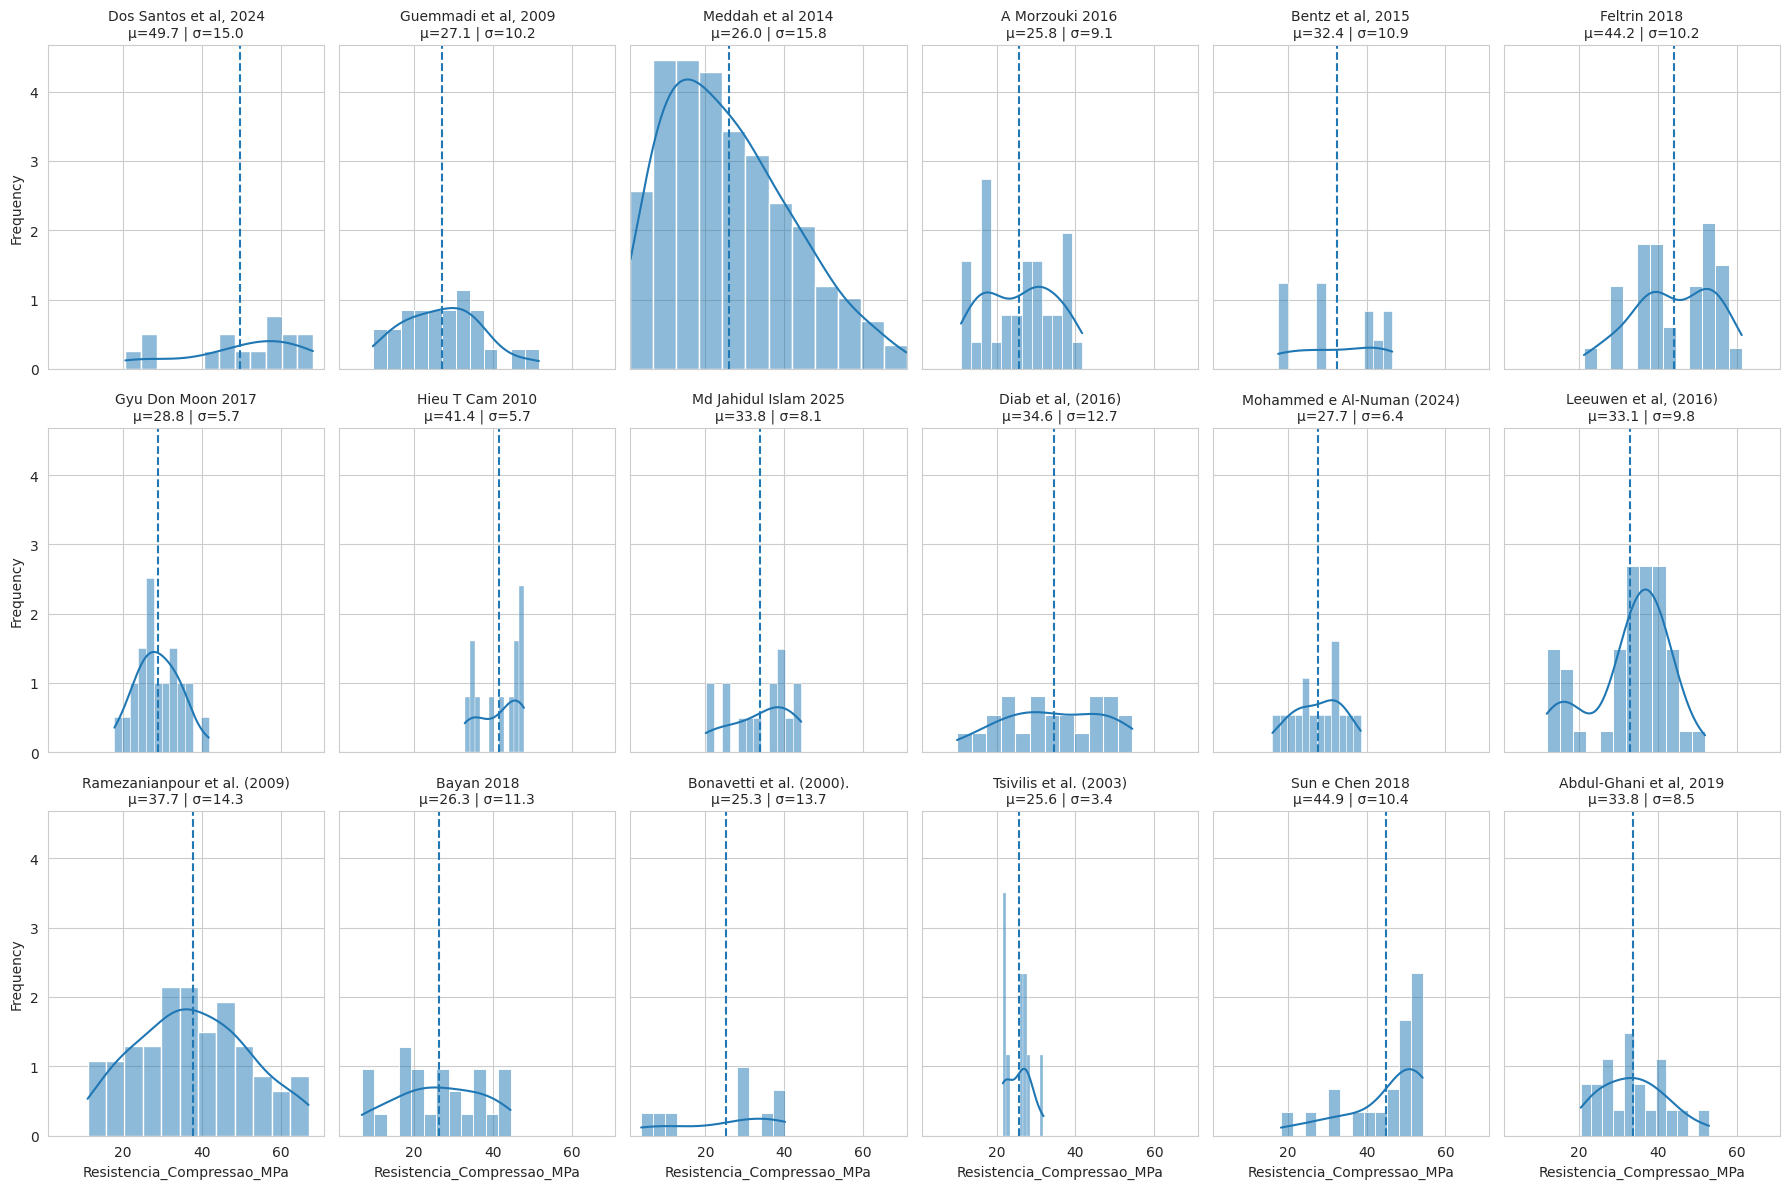

In [53]:
sns.set_style("whitegrid")
autores = df_resistencia['Autores/ano'].unique()
fig, axes = plt.subplots(
    nrows=3,
    ncols=int(np.ceil(len(autores) / 3)),
    figsize=(18, 4*3),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

xmin = df_resistencia['Resistencia_Compressao_MPa'].min()
xmax = df_resistencia['Resistencia_Compressao_MPa'].max()

for i, autor in enumerate(autores):

    df_autor = df_resistencia[
        df_resistencia['Autores/ano'] == autor
    ]
    media = df_autor['Resistencia_Compressao_MPa'].mean()
    std = df_autor['Resistencia_Compressao_MPa'].std()
    sns.histplot(
        data=df_autor,
        x='Resistencia_Compressao_MPa',
        bins=12,
        kde=True,
        stat='frequency',
        ax=axes[i]
    )
    axes[i].axvline(
        media,
        linestyle='--'
    )
    axes[i].set_title(
        f'{autor}\nμ={media:.1f} | σ={std:.1f}',
        fontsize=10
    )
    axes[i].set_xlim(xmin, xmax)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [54]:
columns = df_resistencia.columns

target_list = {'Resistencia_Compressao_MPa', 'Relacao_Agua_Cimento', 'Relacao_Agua_Aglomerante', 
               'Superplastificante_kg_m3', 'Filer_Calcario_kg_m3', 'Agua_kg_m3', 'Cimento_kg_m3',
               'Agregado_Graudo_Total_kg_m3', 'Agregado_Miudo_Total_kg_m3'}

outliers_idx = {}
for column in target_list:
    data = df_resistencia[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()
    if outliers_idx[column]:
        print(f"{column}: {len(outliers_idx[column])} outliers")
        print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}, Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
        for idx in sorted(outliers_idx[column], key=lambda x: data[x], reverse=True):  # Mostrar até 5 outliers
            print(f"  Index: {idx}, Value: {data[idx]}")
        print()

Agua_kg_m3: 25 outliers
Q1: 163.5, Q3: 186.0, IQR: 22.5, Lower Bound: 129.75, Upper Bound: 219.75
  Index: 438, Value: 129.5
  Index: 439, Value: 129.5
  Index: 440, Value: 129.5
  Index: 441, Value: 129.5
  Index: 442, Value: 129.5
  Index: 443, Value: 129.5
  Index: 444, Value: 129.5
  Index: 445, Value: 129.5
  Index: 446, Value: 129.5
  Index: 447, Value: 129.5
  Index: 448, Value: 129.5
  Index: 449, Value: 129.5
  Index: 450, Value: 129.5
  Index: 451, Value: 129.5
  Index: 452, Value: 129.5
  Index: 453, Value: 129.5
  Index: 454, Value: 129.5
  Index: 455, Value: 129.5
  Index: 456, Value: 129.5
  Index: 457, Value: 129.5
  Index: 458, Value: 129.5
  Index: 459, Value: 129.5
  Index: 460, Value: 129.5
  Index: 461, Value: 129.5
  Index: 462, Value: 129.5

Resistencia_Compressao_MPa: 1 outliers
Q1: 21.5, Q3: 40.95, IQR: 19.450000000000003, Lower Bound: -7.675000000000004, Upper Bound: 70.125
  Index: 187, Value: 71.0

Relacao_Agua_Cimento: 21 outliers
Q1: 0.5, Q3: 0.74, IQR: 0.2

In [55]:
# 1. Imputação inteligente: Preenche o Blaine vazio com a mediana da sua respectiva Classe
df_resistencia['Finura_Cimento_Blaine_m2_kg'] = df_resistencia.groupby('Classe_Cim_OpA')['Finura_Cimento_Blaine_m2_kg'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Rede de segurança: Se uma classe inteira não tiver nenhum dado de Blaine, 
# usamos a mediana global do dataset para os retardatários.
mediana_global_blaine = df_resistencia['Finura_Cimento_Blaine_m2_kg'].median()
df_resistencia['Finura_Cimento_Blaine_m2_kg'] = df_resistencia['Finura_Cimento_Blaine_m2_kg'].fillna(mediana_global_blaine)

# Verificação final para garantir que zeramos os nulos
print(f"Valores nulos no Blaine após tratamento: {df_resistencia['Finura_Cimento_Blaine_m2_kg'].isna().sum()}")

Valores nulos no Blaine após tratamento: 0


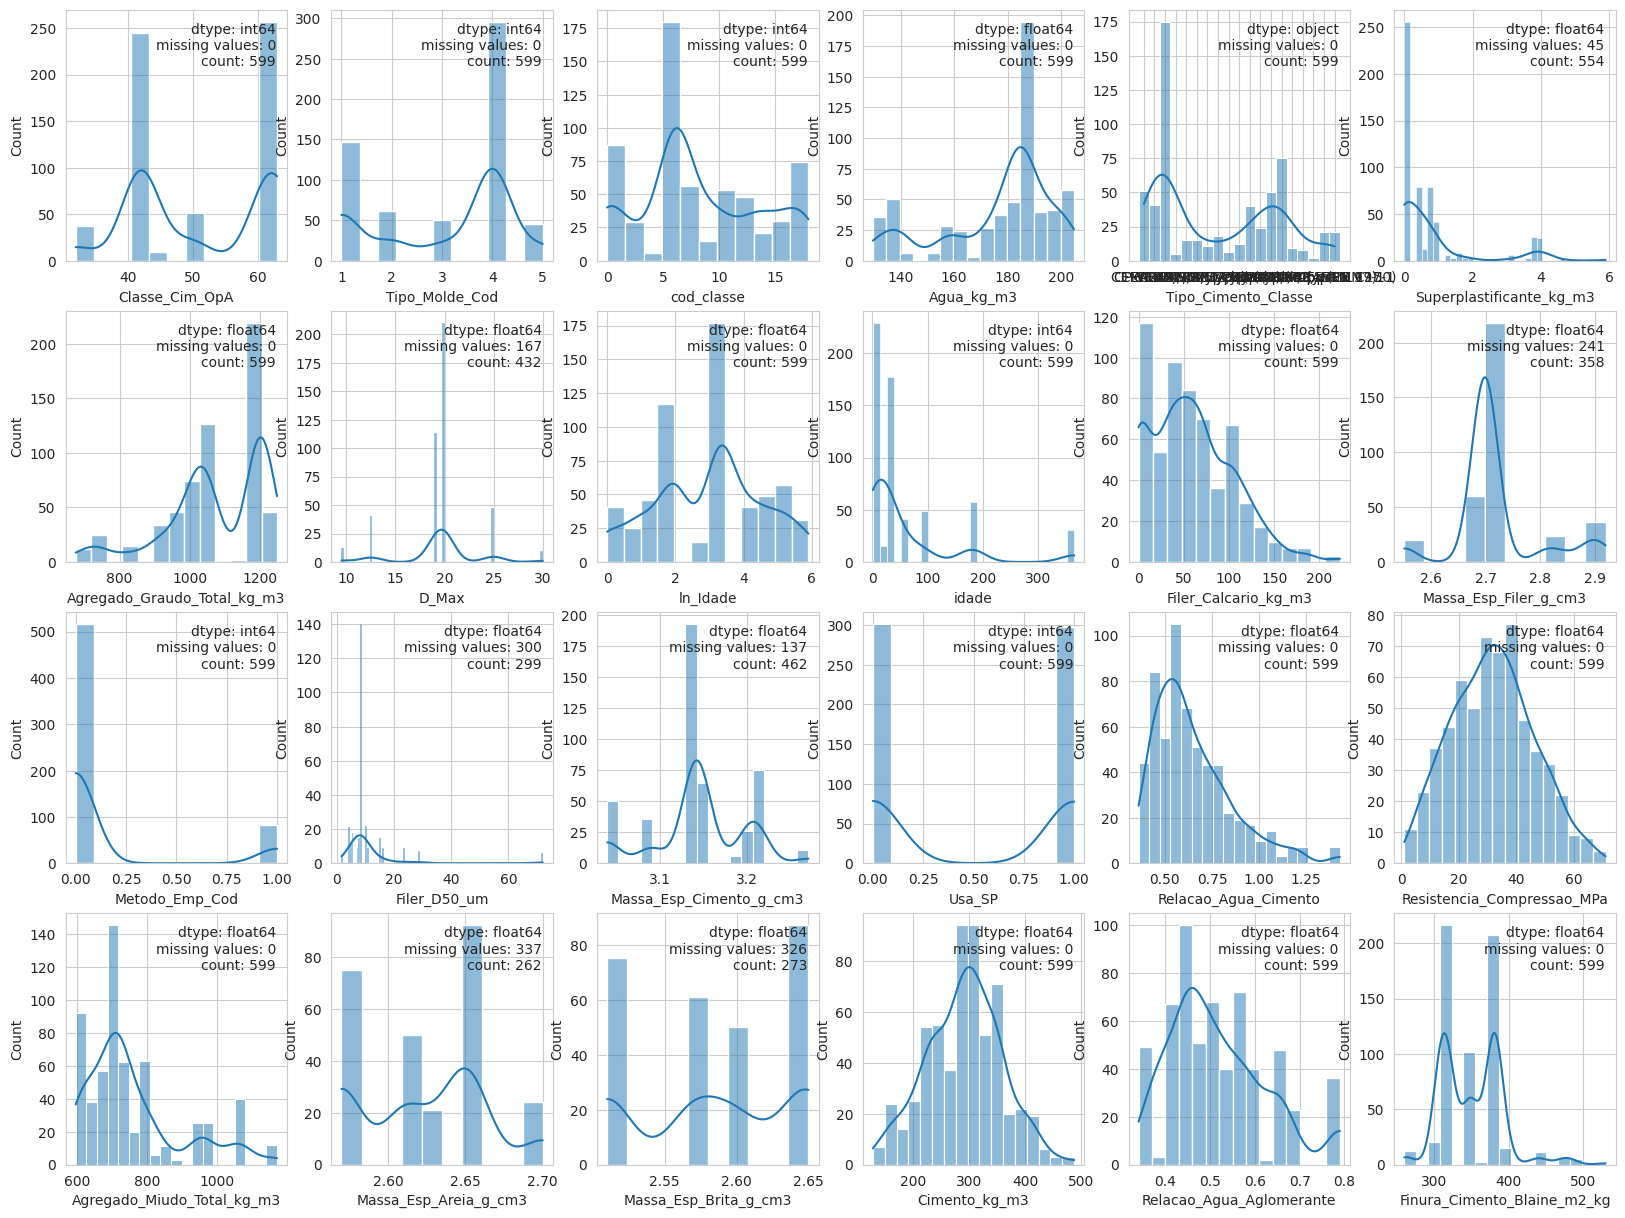

In [56]:
columns = set(df_resistencia.columns)
exclude = {'Autores/ano', 'ID_Mistura'}
columns -= exclude
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))
axes = axes.flatten()

for i, column in enumerate(columns):
    text = (f"dtype: {df_resistencia[column].dtype}\n"
            f"missing values: {df_resistencia[column].isnull().sum()}\n"
            f"count: {df_resistencia[column].count()}")
    axes[i].text(0.95, 0.95, text, transform=axes[i].transAxes,
                        verticalalignment='top', horizontalalignment='right')
    sns.histplot(df_resistencia[column], ax=axes[i], kde=True)

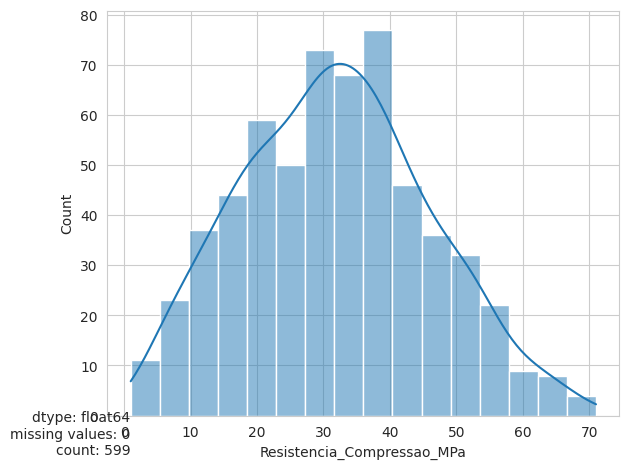

In [57]:
text = (f"dtype: {df_resistencia['Resistencia_Compressao_MPa'].dtype}\n"
            f"missing values: {df_resistencia['Resistencia_Compressao_MPa'].isnull().sum()}\n"
            f"count: {df_resistencia['Resistencia_Compressao_MPa'].count()}")
plt.text(0.95, 0.95, text, verticalalignment='top', horizontalalignment='right')
sns.histplot(df_resistencia['Resistencia_Compressao_MPa'], kde=True)
plt.tight_layout()
plt.show()

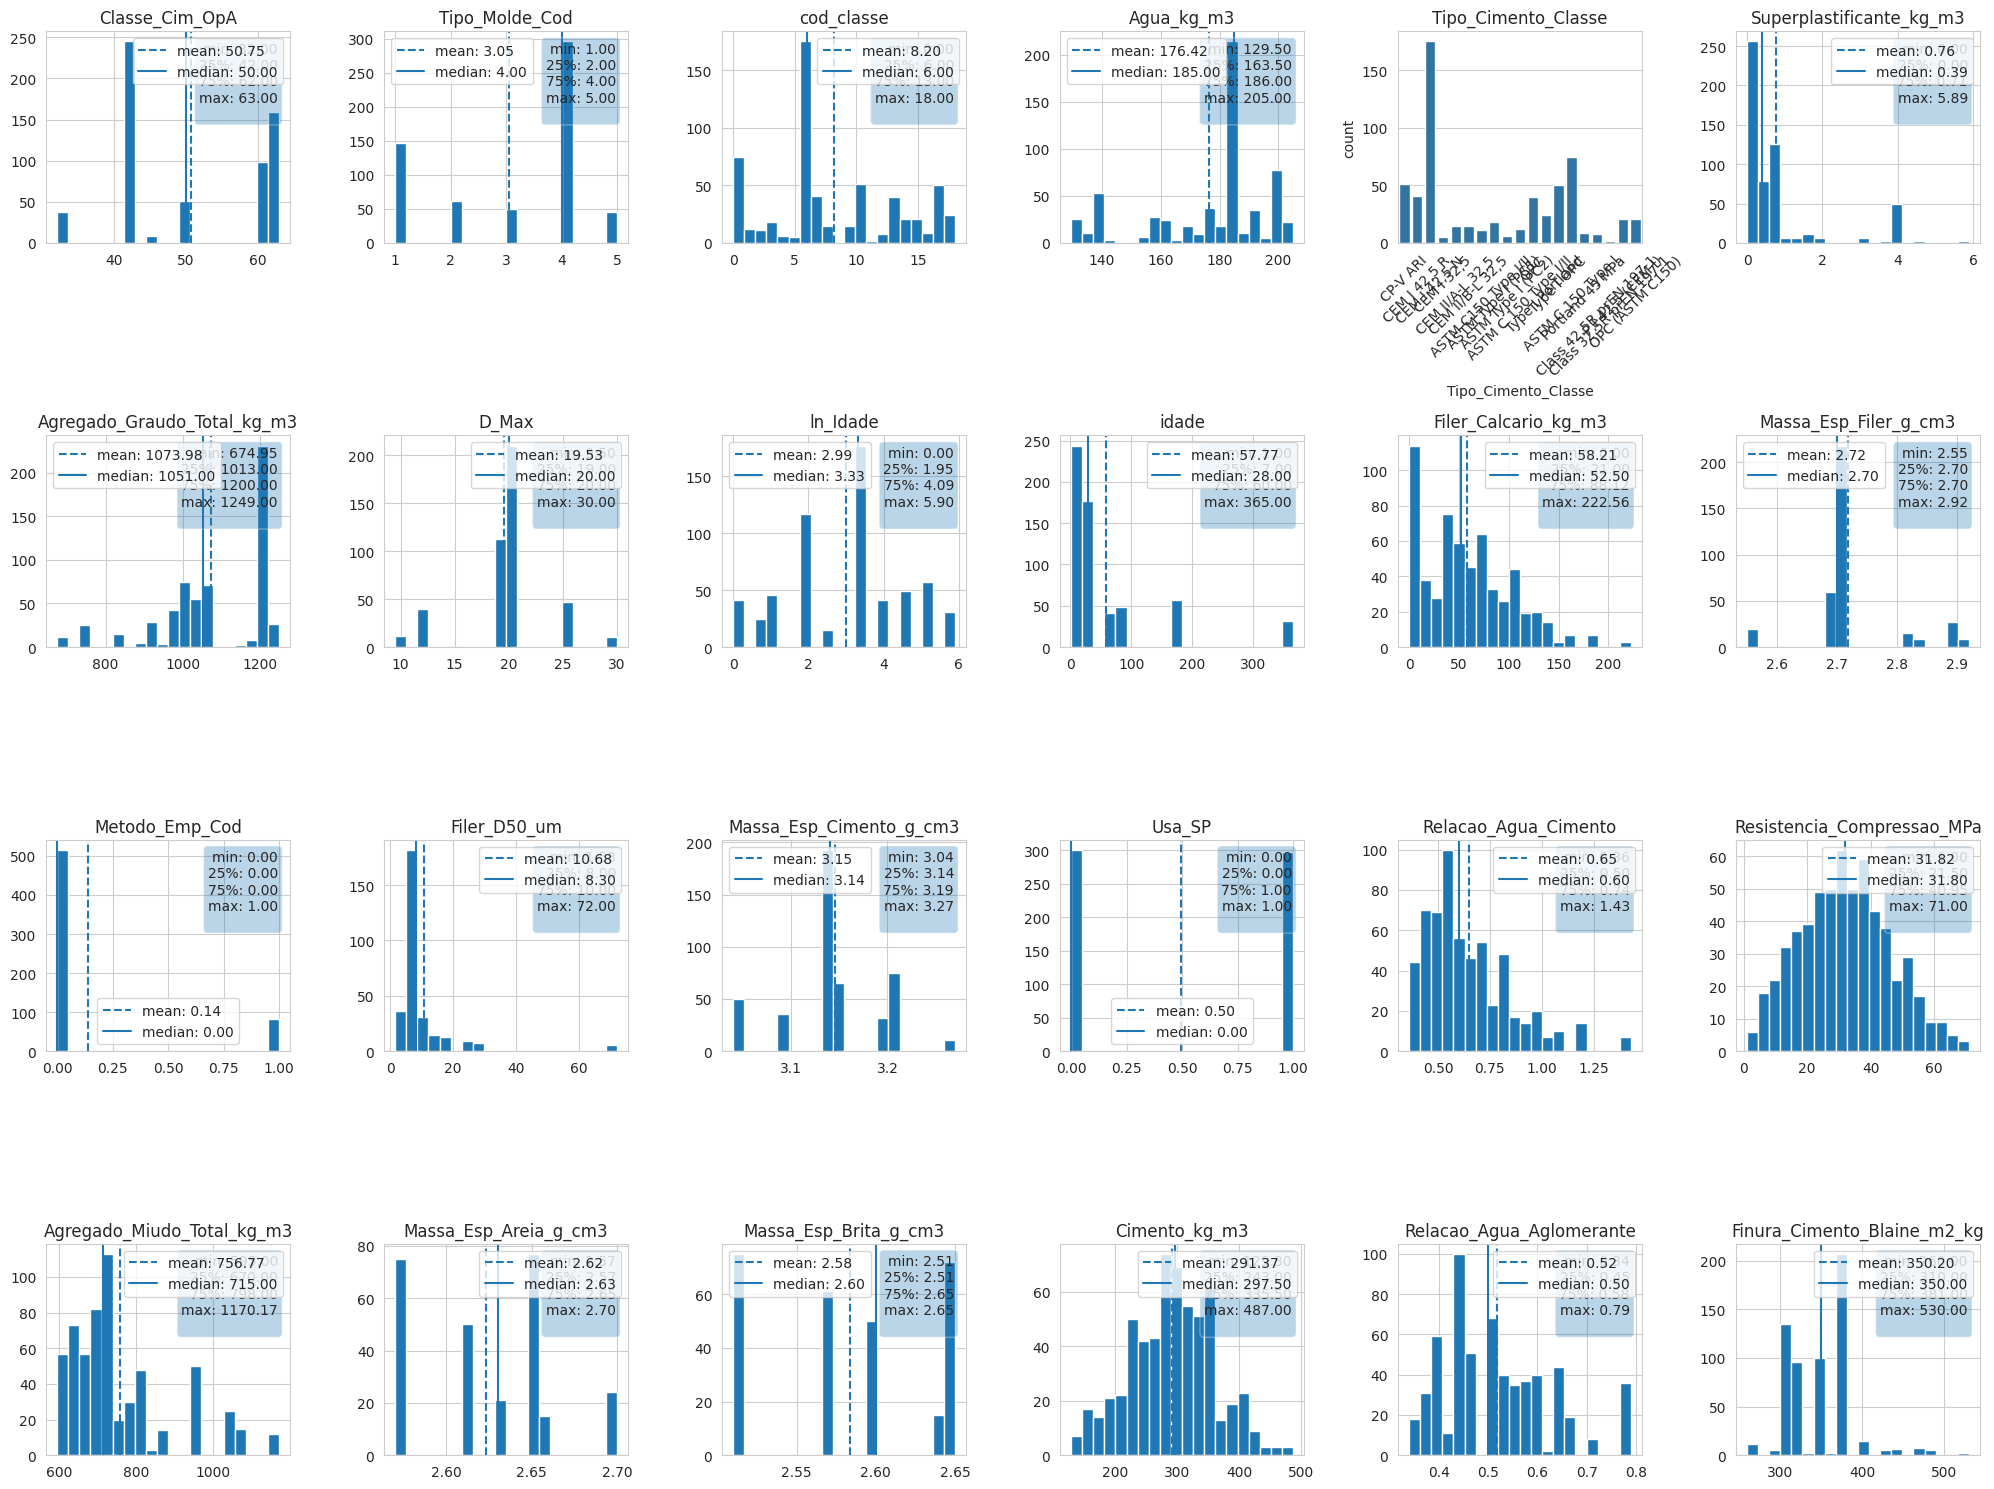

In [58]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))

axes = axes.flatten()

for i, column in enumerate(columns):
    ax = axes[i]
    data = df_resistencia[column]
    if data.dtype == 'object':
        ax.set_title(column)
        sns.countplot(x=data, ax=ax)
        ax.tick_params(axis='x', rotation=45)
        continue

    ax.set_title(column)
    ax.hist(data, bins=20)
    
    stats = data.describe()
    
    # Linhas de referência
    ax.axvline(stats['mean'], linestyle='--', label=f"mean: {stats['mean']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"median: {stats['50%']:.2f}")
    
    # Texto com resumo
    text = (
        f"min: {stats['min']:.2f}\n"
        f"25%: {stats['25%']:.2f}\n"
        f"75%: {stats['75%']:.2f}\n"
        f"max: {stats['max']:.2f}\n"
    )
    
    ax.text(
        0.95, 0.95, text,
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(boxstyle="round", alpha=0.3)
    )
    
    ax.legend()

plt.tight_layout()
plt.show()

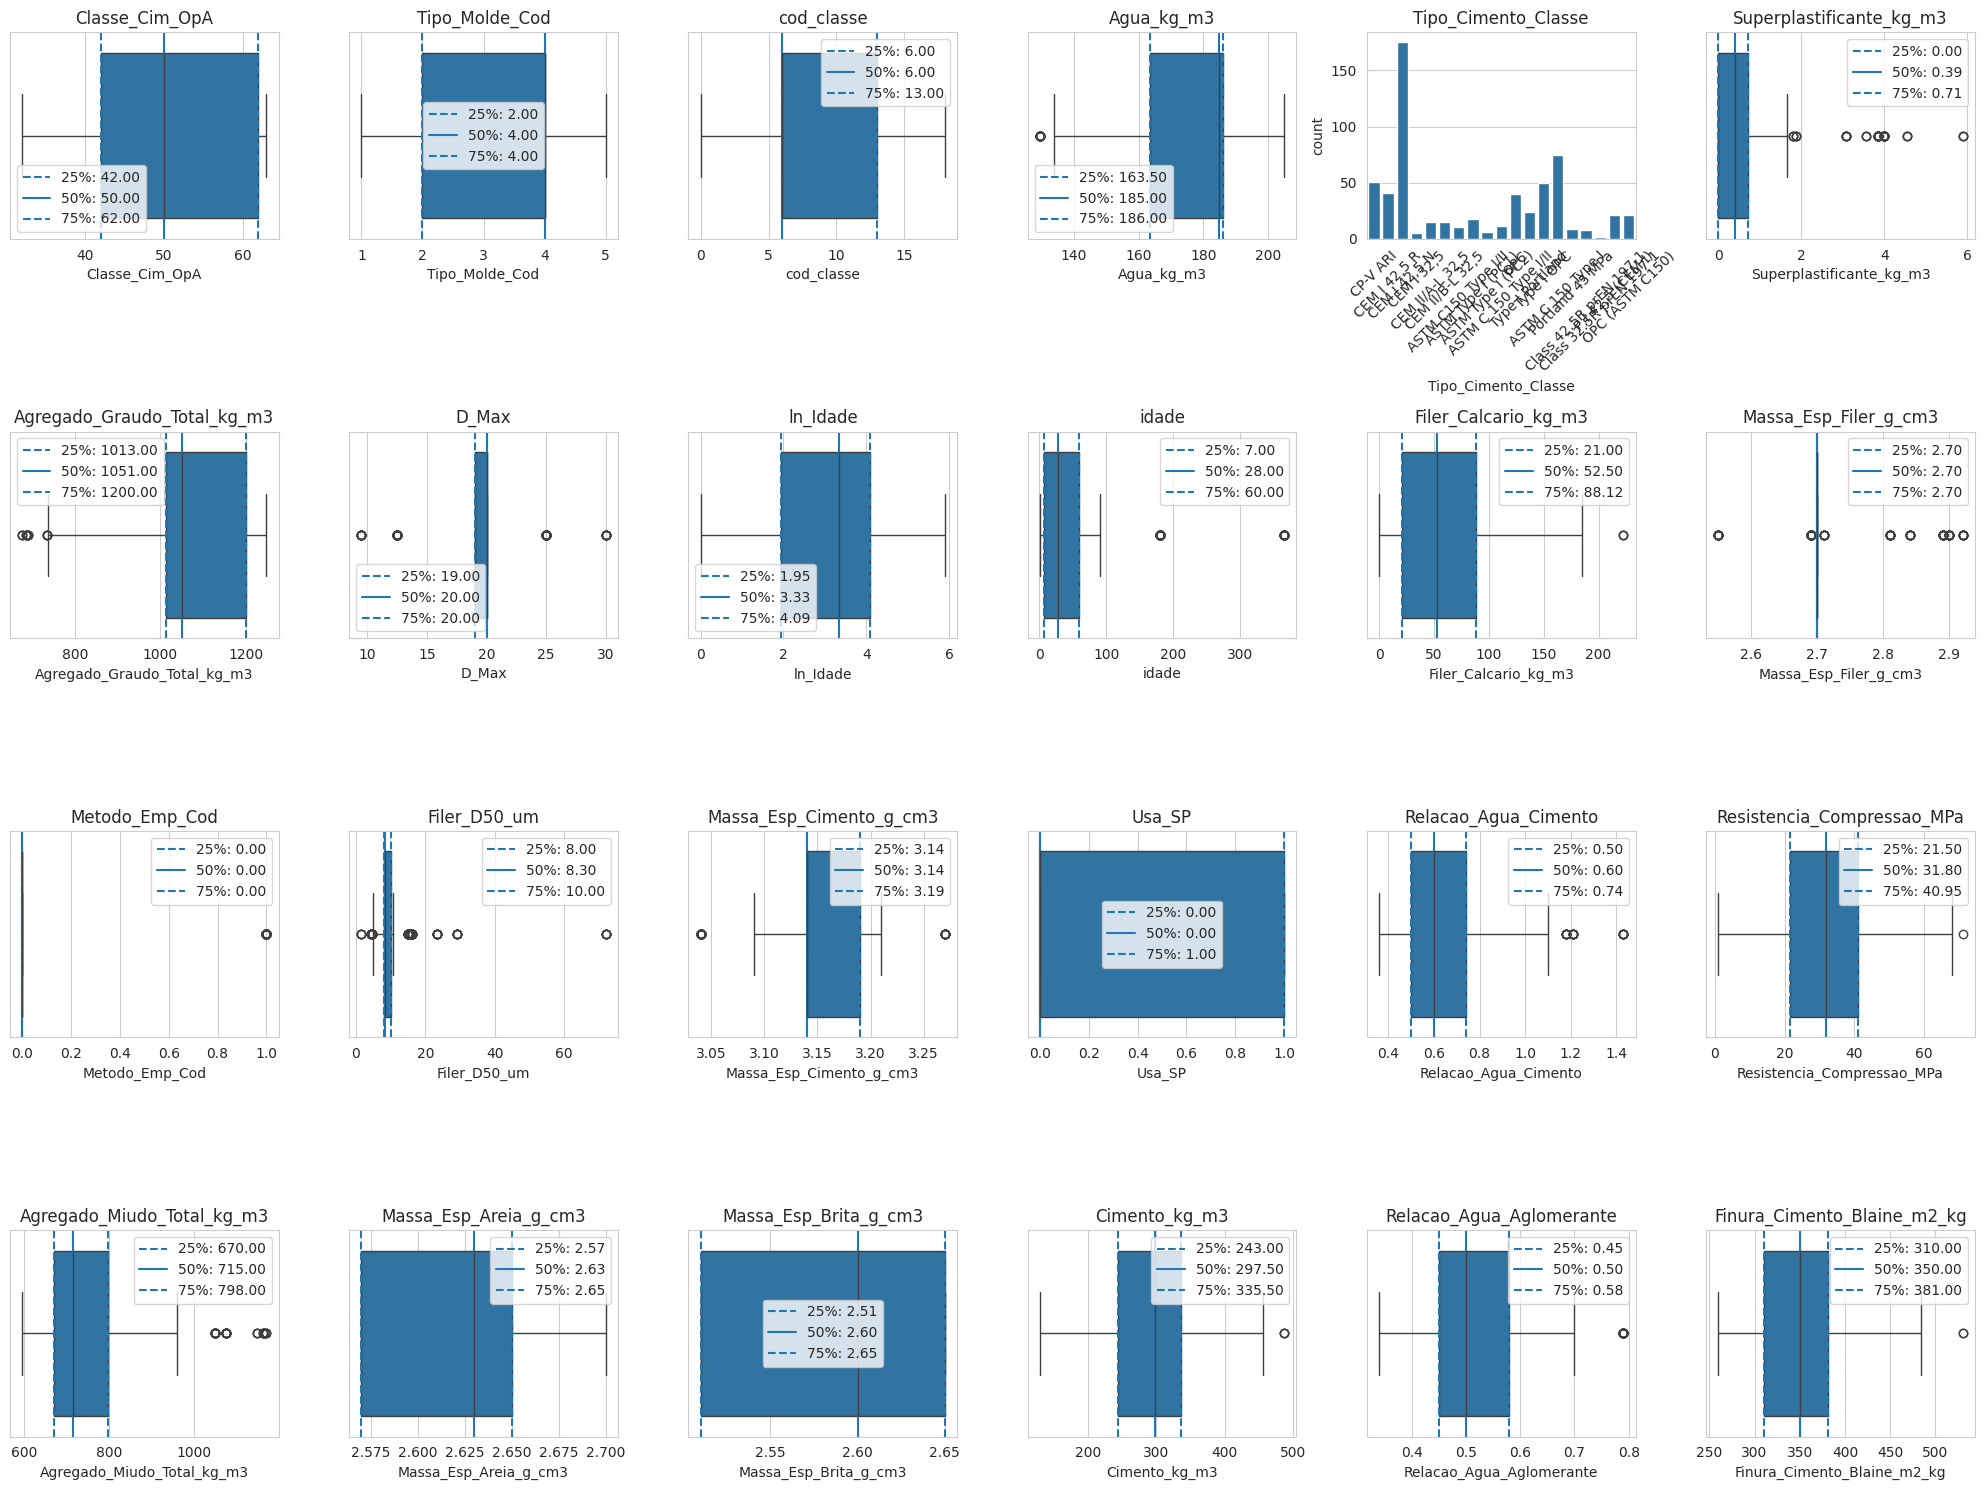

In [59]:
figure, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))

axes = axes.flatten()

for i, column in enumerate(columns):
    ax = axes[i]
    data = df_resistencia[column]
    if data.dtype == 'object':
        ax.set_title(column)
        sns.countplot(x=data, ax=ax)
        ax.tick_params(axis='x', rotation=45)
        continue

    ax.set_title(column)
    sns.boxplot(x=data, ax=ax)
    
    stats = data.describe()

    # Linhas de referência
    ax.axvline(stats['25%'], linestyle='--', label=f"25%: {stats['25%']:.2f}")
    ax.axvline(stats['50%'], linestyle='-', label=f"50%: {stats['50%']:.2f}")
    ax.axvline(stats['75%'], linestyle='--', label=f"75%: {stats['75%']:.2f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [60]:
# Removendo coluna 'idade' de forma efetiva
df_resistencia.drop(columns=['idade'], inplace=True)

In [61]:
df_resistencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Autores/ano                  599 non-null    object 
 1   ID_Mistura                   599 non-null    object 
 2   Tipo_Cimento_Classe          599 non-null    object 
 3   Massa_Esp_Cimento_g_cm3      462 non-null    float64
 4   Finura_Cimento_Blaine_m2_kg  599 non-null    float64
 5   Massa_Esp_Filer_g_cm3        358 non-null    float64
 6   Massa_Esp_Areia_g_cm3        262 non-null    float64
 7   Massa_Esp_Brita_g_cm3        273 non-null    float64
 8   Cimento_kg_m3                599 non-null    float64
 9   Filer_Calcario_kg_m3         599 non-null    float64
 10  Agua_kg_m3                   599 non-null    float64
 11  Agregado_Miudo_Total_kg_m3   599 non-null    float64
 12  Agregado_Graudo_Total_kg_m3  599 non-null    float64
 13  Superplastificante_k

In [62]:
# 1. Definindo as colunas do "DNA da Resistência"
colunas_cluster = [
    'Classe_Cim_OpA', 
    'Finura_Cimento_Blaine_m2_kg', 
    'Relacao_Agua_Cimento', 
    'Cimento_kg_m3'
]

# Separando apenas os dados que o HDBSCAN vai "enxergar"
X_cluster = df_resistencia[colunas_cluster].copy()

# 2. Padronização (Obrigatório para algoritmos de distância)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. Configurando e Treinando o HDBSCAN
# min_cluster_size: O tamanho MÍNIMO para um grupo ser considerado uma "família". 
# (Ex: se colocar 15, qualquer grupo com menos de 15 traços parecidos é considerado anomalia/ruído)
hdbscan_modelo = HDBSCAN(
    min_cluster_size=5,     # A SALVAÇÃO: Permite que famílias raras (como o CEM I 32,5) sobrevivam
    min_samples=2,          # A LENIÊNCIA: Como min_cluster_size caiu, diminuir o min_samples impede que o modelo crie clusters demais. Ele aceita que os pontos estejam um pouquinho mais espalhados.
    cluster_selection_epsilon=0.5, # O IMÃ: Como os dados estão em StandardScaler, uma distância de 0.5 ajuda a fundir aqueles cimentos com nomes diferentes, mas química igual.
    metric='euclidean'
)

# O HDBSCAN já treina e devolve os rótulos (-1 significa RUÍDO/OUTLIER)
df_resistencia['Cluster_ID'] = hdbscan_modelo.fit_predict(X_scaled)

# 4. Avaliando o estrago (Quantos grupos achou e quantos outliers isolou)
print("Distribuição das Famílias Encontradas:")
print(df_resistencia['Cluster_ID'].value_counts().sort_index())

# 5. O SEGREDO: Limpando a base de treino!
# Nós deletamos os ruídos (-1) da base que vai para a árvore de decisão
df_resistencia_limpo = df_resistencia[df_resistencia['Cluster_ID'] != -1].copy()

print(f"\nTraços Originais: {len(df_resistencia)}")
print(f"Traços Removidos (Ruído): {len(df_resistencia) - len(df_resistencia_limpo)}")
print(f"Base Limpa para a Árvore: {len(df_resistencia_limpo)}")

Distribuição das Famílias Encontradas:
Cluster_ID
-1      13
 0       6
 1       5
 2      12
 3      15
 4       7
 5      11
 6       6
 7      10
 8       9
 9       5
 10      5
 11    192
 12     15
 13    219
 14     18
 15      6
 16     27
 17     18
Name: count, dtype: int64

Traços Originais: 599
Traços Removidos (Ruído): 13
Base Limpa para a Árvore: 586


In [63]:
df_resistencia_limpo["Usa_SP"] = df_resistencia_limpo["Usa_SP"].astype(bool)

In [64]:
df_resistencia_limpo.Usa_SP.dtype

dtype('bool')

In [65]:
# ==========================================
# CONSTANTES
# ==========================================
# 1. Definimos a lista dos materiais que precisam da correção de densidade
colunas_densidade = [
    'Massa_Esp_Cimento_g_cm3',
    'Massa_Esp_Areia_g_cm3',
    'Massa_Esp_Brita_g_cm3',
    'Massa_Esp_Filer_g_cm3',
    'Superplastificante_kg_m3',
    'D_Max', 'Filer_D50_um'
]

for col in colunas_densidade:
    # Passo A: Imputação com Média do próprio Cluster
    df_resistencia_limpo[col] = df_resistencia_limpo.groupby('Cluster_ID')[col].transform(
        lambda x: x.fillna(x.mean())
    )
    
    # Passo B: A Trava de Segurança (Fallback para a Média Global)
    media_global = df_resistencia_limpo[col].mean()
    df_resistencia_limpo[col] = df_resistencia_limpo[col].fillna(media_global)
    
    # Verificação em tempo real
    nulos_restantes = df_resistencia_limpo[col].isna().sum()
    print(f"✅ {col}: {nulos_restantes} nulos restantes.")

# Tratamento especifico para Superplastificante_kg_m3 que depende diretamente de Usa_SP
df_resistencia_limpo.loc[~df_resistencia_limpo['Usa_SP'], 'Superplastificante_kg_m3'] = 0.0

# Quando não há filler seu tamanho deve ser 0, não faz sentido ter um D50.
df_resistencia_limpo.loc[df_resistencia_limpo['Filer_Calcario_kg_m3'] == 0, 'Filer_D50_um'] = 0.0

df_resistencia_limpo['Massa_Esp_Cimento_kg_m3'] = df_resistencia_limpo['Massa_Esp_Cimento_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia_limpo['Massa_Esp_Areia_kg_m3'] =  df_resistencia_limpo['Massa_Esp_Areia_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia_limpo['Massa_Esp_Brita_kg_m3'] = df_resistencia_limpo['Massa_Esp_Brita_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia_limpo['Massa_Esp_Filer_kg_m3'] = df_resistencia_limpo['Massa_Esp_Filer_g_cm3'] * 1000  # Convertendo de g/cm³ para kg/m³
df_resistencia_limpo.drop(columns=['Massa_Esp_Cimento_g_cm3', 'Massa_Esp_Areia_g_cm3', 'Massa_Esp_Brita_g_cm3', 'Massa_Esp_Filer_g_cm3'], inplace=True)

# 2. Atualizando as variáveis que vão alimentar a sua matriz de volumes absolutos
DENSIDADE_CIMENTO = df_resistencia_limpo['Massa_Esp_Cimento_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AREIA = df_resistencia_limpo['Massa_Esp_Areia_kg_m3']  # Usando a coluna já convertida
DENSIDADE_BRITA = df_resistencia_limpo['Massa_Esp_Brita_kg_m3']  # Usando a coluna já convertida
DENSIDADE_FILER = df_resistencia_limpo['Massa_Esp_Filer_kg_m3']  # Usando a coluna já convertida
DENSIDADE_AGUA = 1000
DENSIDADE_SP = 1100

✅ Massa_Esp_Cimento_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Areia_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Brita_g_cm3: 0 nulos restantes.
✅ Massa_Esp_Filer_g_cm3: 0 nulos restantes.
✅ Superplastificante_kg_m3: 0 nulos restantes.
✅ D_Max: 0 nulos restantes.
✅ Filer_D50_um: 0 nulos restantes.


In [66]:
# Dicionário de Mapeamento do Coeficiente 's' do fib Model Code
# Baseado na norma europeia (EN 197-1), ASTM (C150) e brasileira
mapa_coeficiente_s = {
    # s = 0.20 (Rápido / Alta Resistência Inicial)
    'CP-V ARI': 0.20,
    'CEM I 42,5 R': 0.20,
    'Class 42.5R prEN 197-1': 0.20,
    'Portland 45 MPa': 0.20, # Assumindo alta resistência inicial

    # s = 0.25 (Normal / OPC Tradicional)
    'CEM I 42,5 N': 0.25,
    'ASTM C150 Type I/II': 0.25,
    'ASTM Type I (PC1)': 0.25,
    'ASTM Type I (PC2)': 0.25,
    'ASTM C 150 Type I/II': 0.25,
    'ASTM C 150 Type I': 0.25,
    'OPC': 0.25,
    'Type I Portland': 0.25,
    'Type I OPC': 0.25,
    'OPC (ASTM C150)': 0.25,
    'P,I 42,5 (CEM I)': 0.25, 

    # s = 0.38 (Lento / Baixa classe ou com adições como Fíler Calcário - L)
    'CEM I 32,5': 0.38, # 32.5 sem o 'R' geralmente é Normal/Lento (N)
    'CEM II/A-L 32,5': 0.38, 
    'CEM II/B-L 32,5': 0.38
}

In [67]:
# ==========================================
# FEATURE ENGINEERING - CONCRETE COMPRESSIVE STRENGTH
# ==========================================

EPS = np.finfo(float).eps

colunas_densidade = [
    'Massa_Esp_Cimento_g_cm3',
    'Massa_Esp_Areia_g_cm3',
    'Massa_Esp_Brita_g_cm3',
    'Massa_Esp_Filer_g_cm3',
    'Superplastificante_kg_m3',
    'D_Max', 
    'Filer_D50_um'
]

# ==========================================
# 1. CÁLCULO DE VOLUMES ABSOLUTOS
# ==========================================
print("\n" + "=" * 50)
print("1. VOLUMES ABSOLUTOS")
print("=" * 50)

df_resistencia_limpo['vol_cimento'] = pd.to_numeric(df_resistencia_limpo['Cimento_kg_m3'], errors='coerce') / df_resistencia_limpo['Massa_Esp_Cimento_kg_m3']
df_resistencia_limpo['vol_agua'] = pd.to_numeric(df_resistencia_limpo['Agua_kg_m3'], errors='coerce') / DENSIDADE_AGUA
df_resistencia_limpo['vol_filer'] = pd.to_numeric(df_resistencia_limpo['Filer_Calcario_kg_m3'], errors='coerce') / df_resistencia_limpo['Massa_Esp_Filer_kg_m3']
df_resistencia_limpo['vol_areia'] = pd.to_numeric(df_resistencia_limpo['Agregado_Miudo_Total_kg_m3'], errors='coerce') / df_resistencia_limpo['Massa_Esp_Areia_kg_m3']
df_resistencia_limpo['vol_brita'] = pd.to_numeric(df_resistencia_limpo['Agregado_Graudo_Total_kg_m3'], errors='coerce') / df_resistencia_limpo['Massa_Esp_Brita_kg_m3']
df_resistencia_limpo['vol_sp'] = pd.to_numeric(df_resistencia_limpo['Superplastificante_kg_m3'], errors='coerce') / DENSIDADE_SP

# ==========================================
# 2. FECHAMENTO VOLUMÉTRICO E POROSIDADE
# ==========================================
print("\n" + "=" * 50)
print("2. FECHAMENTO VOLUMÉTRICO E POROSIDADE")
print("=" * 50)

# Volume total de materiais
df_resistencia_limpo['volume_materiais'] = (
    df_resistencia_limpo['vol_cimento'] +
    df_resistencia_limpo['vol_agua'] +
    df_resistencia_limpo['vol_filer'] +
    df_resistencia_limpo['vol_areia'] +
    df_resistencia_limpo['vol_brita'] +
    df_resistencia_limpo['vol_sp']
)

# Ar aprisionado
df_resistencia_limpo['vol_ar_aprisionado'] = (
    1.0 - df_resistencia_limpo['volume_materiais']
).clip(lower=0)

# Porosidade e índice de vazios
df_resistencia_limpo['porosidade_volumetrica_inicial'] = (
    df_resistencia_limpo['vol_agua'] + df_resistencia_limpo['vol_ar_aprisionado']
)

df_resistencia_limpo['vol_solidos_totais'] = (
    df_resistencia_limpo['vol_cimento'] +
    df_resistencia_limpo['vol_filer'] +
    df_resistencia_limpo['vol_areia'] +
    df_resistencia_limpo['vol_brita']
)

df_resistencia_limpo['indice_vazios'] = (
    df_resistencia_limpo['porosidade_volumetrica_inicial'] /
    df_resistencia_limpo['vol_solidos_totais'].clip(lower=EPS)
)

# ==========================================
# 3. ESTRUTURA DO CONCRETO
# ==========================================
print("\n" + "=" * 50)
print("3. ESTRUTURA DO CONCRETO")
print("=" * 50)

# Volumes de agregados e pasta
df_resistencia_limpo['vol_agregados'] = (
    df_resistencia_limpo['vol_areia'] + df_resistencia_limpo['vol_brita']
)

df_resistencia_limpo['vol_pasta'] = (
    df_resistencia_limpo['vol_cimento'] +
    df_resistencia_limpo['vol_agua'] +
    df_resistencia_limpo['vol_filer']
)

df_resistencia_limpo['vol_po_total'] = (
    df_resistencia_limpo['vol_cimento'] + df_resistencia_limpo['vol_filer']
)

# Proporções
df_resistencia_limpo['pasta_agregado'] = (
    df_resistencia_limpo['vol_pasta'] /
    df_resistencia_limpo['vol_agregados'].clip(lower=EPS)
)

df_resistencia_limpo['fracao_agregados'] = df_resistencia_limpo['vol_agregados']  # Já está em base 1.0

# ==========================================
# 4. RELAÇÕES DE MASSA E FINOS
# ==========================================
print("\n" + "=" * 50)
print("4. RELAÇÕES DE MASSA E FINOS")
print("=" * 50)

# Aglomerante total
df_resistencia_limpo['aglomerante_total'] = (
    df_resistencia_limpo['Cimento_kg_m3'] + df_resistencia_limpo['Filer_Calcario_kg_m3']
)

# Relação água/cimento (inversa)
df_resistencia_limpo['inv_a_c'] = (
    1.0 / df_resistencia_limpo['Relacao_Agua_Cimento'].clip(lower=EPS)
)

# Fator água/pó (volumétrico)
df_resistencia_limpo['fator_agua_po'] = (
    df_resistencia_limpo['vol_agua'] /
    df_resistencia_limpo['vol_po_total'].clip(lower=EPS)
)

# Proporção de finos
df_resistencia_limpo['finos_total'] = (
    df_resistencia_limpo['Filer_Calcario_kg_m3'] /
    df_resistencia_limpo['Cimento_kg_m3'].clip(lower=EPS)
)

df_resistencia_limpo['taxa_filer_inerte'] = (
    df_resistencia_limpo['Filer_Calcario_kg_m3'] /
    df_resistencia_limpo['aglomerante_total'].clip(lower=EPS)
)

# ==========================================
# 5. SUPERPLASTIFICANTE
# ==========================================
print("\n" + "=" * 50)
print("5. SUPERPLASTIFICANTE")
print("=" * 50)

df_resistencia_limpo['taxa_sp_cimento'] = (
    df_resistencia_limpo['Superplastificante_kg_m3'] /
    df_resistencia_limpo['Cimento_kg_m3'].clip(lower=EPS)
)

df_resistencia_limpo['taxa_sp_aglomerante'] = (
    df_resistencia_limpo['Superplastificante_kg_m3'] /
    df_resistencia_limpo['aglomerante_total'].clip(lower=EPS)
)

# ==========================================
# 6. GRANULOMETRIA
# ==========================================
print("\n" + "=" * 50)
print("6. GRANULOMETRIA")
print("=" * 50)

df_resistencia_limpo['range_granulometrico'] = (
    (df_resistencia_limpo['D_Max'] * 1000) /
    (df_resistencia_limpo['Filer_D50_um'] + EPS)
)

# ==========================================
# 7. FEATURES TEMPORAIS BÁSICAS
# ==========================================
print("\n" + "=" * 50)
print("7. FEATURES TEMPORAIS BÁSICAS")
print("=" * 50)

# Idade em dias
idade_dias = np.exp(df_resistencia_limpo['ln_Idade'])

# Interação idade × a/c
df_resistencia_limpo['idade_fator_agua'] = (
    df_resistencia_limpo['ln_Idade'] /
    df_resistencia_limpo['Relacao_Agua_Cimento'].clip(lower=EPS)
)

# ==========================================
# 8. MODELO DE FÉRET
# ==========================================
print("\n" + "=" * 50)
print("8. MODELO DE FÉRET")
print("=" * 50)

# Parâmetro de Féret básico
df_resistencia_limpo['parametro_feret'] = (
    df_resistencia_limpo['vol_cimento'] /
    (
        df_resistencia_limpo['vol_cimento'] +
        df_resistencia_limpo['vol_agua'] +
        df_resistencia_limpo['vol_ar_aprisionado']
    ).clip(lower=EPS)
) ** 2

# Interação com idade
df_resistencia_limpo['idade_feret'] = (
    df_resistencia_limpo['ln_Idade'] * df_resistencia_limpo['parametro_feret']
)

# Féret corrigido por condições de contorno (CBC)
vazios_agregados_estimado = df_resistencia_limpo['vol_agregados'] * 0.30

df_resistencia_limpo['saturacao_pasta'] = (
    df_resistencia_limpo['vol_pasta'] / vazios_agregados_estimado.clip(lower=EPS)
)

saturacao_pasta_mask = df_resistencia_limpo['saturacao_pasta'].clip(upper=1.0)

df_resistencia_limpo['qualidade_adensamento'] = np.exp(-df_resistencia_limpo['vol_ar_aprisionado'] * 50)

df_resistencia_limpo['fator_resistencia_rocha'] = (
        (df_resistencia_limpo['Massa_Esp_Brita_kg_m3'] - 2400).clip(lower=0) / (3000 - 2400)
    ).clip(upper=1.0)

df_resistencia_limpo['indice_conformidade_feret'] = (
    saturacao_pasta_mask * 
    df_resistencia_limpo['qualidade_adensamento'] * 
    df_resistencia_limpo['fator_resistencia_rocha']
)

df_resistencia_limpo['feret_corrigido_contorno'] = (
    df_resistencia_limpo['parametro_feret'] * df_resistencia_limpo['indice_conformidade_feret']
)

# ==========================================
# 9. CINÉTICA DE HIDRATAÇÃO
# ==========================================
print("\n" + "=" * 50)
print("9. CINÉTICA DE HIDRATAÇÃO")
print("=" * 50)

df_resistencia_limpo['potencial_reativo_tempo'] = (
    df_resistencia_limpo['ln_Idade'] * (df_resistencia_limpo['Finura_Cimento_Blaine_m2_kg'] / 1000)
)

df_resistencia_limpo['cinetica_real'] = (
    df_resistencia_limpo['potencial_reativo_tempo'] /
    df_resistencia_limpo['Relacao_Agua_Cimento'].clip(lower=EPS)
)

# ==========================================
# 10. MODELO DE POWERS
# ==========================================
print("\n" + "=" * 50)
print("10. MODELO DE POWERS")
print("=" * 50)

# Baseado em massa
df_resistencia_limpo['pow_gel_space_mass'] = 0.68 / (df_resistencia_limpo['Relacao_Agua_Cimento'] + 0.32)

# Baseado em volume (com ar aprisionado)
df_resistencia_limpo['pow_gel_space_vol'] = (
    (2.06 * df_resistencia_limpo['vol_cimento']) /
    (df_resistencia_limpo['vol_cimento'] + df_resistencia_limpo['vol_agua'] + df_resistencia_limpo['vol_ar_aprisionado'])
)

# Lei cúbica de Powers
df_resistencia_limpo['pow_cubo_vol'] = df_resistencia_limpo['pow_gel_space_vol'] ** 3

# Interação temporal
df_resistencia_limpo['pow_interacao_tempo'] = (
    df_resistencia_limpo['pow_cubo_vol'] * df_resistencia_limpo['ln_Idade']
)

# Razão Powers/Féret
df_resistencia_limpo['razao_powers_feret'] = (
    df_resistencia_limpo['pow_gel_space_vol'] / df_resistencia_limpo['parametro_feret']
)

# ==========================================
# 11. MODELO DE RYSHKEWITCH
# ==========================================
print("\n" + "=" * 50)
print("11. MODELO DE RYSHKEWITCH")
print("=" * 50)

B_empirico = 5.0

# Porosidade real (considerando ar)
porosidade_real = (
    (df_resistencia_limpo['vol_agua'] + df_resistencia_limpo['vol_ar_aprisionado']) /
    df_resistencia_limpo['volume_materiais']
)

# Ryshkewitch inicial
df_resistencia_limpo['ryshkewitch_inicial'] = np.exp(-B_empirico * df_resistencia_limpo['porosidade_volumetrica_inicial'])

# Ryshkewitch real
df_resistencia_limpo['ryshkewitch_real'] = np.exp(-B_empirico * porosidade_real)

# Ryshkewitch cinético
porosidade_atual_estimada = df_resistencia_limpo['porosidade_volumetrica_inicial'] / (df_resistencia_limpo['ln_Idade'] + 1)
df_resistencia_limpo['ryshkewitch_cinetico'] = np.exp(-B_empirico * porosidade_atual_estimada)

# Linearização logarítmica
df_resistencia_limpo['ryshkewitch_linearizado'] = -df_resistencia_limpo['porosidade_volumetrica_inicial']

# ==========================================
# 12. MODELO DE HASSELMANN
# ==========================================
print("\n" + "=" * 50)
print("12. MODELO DE HASSELMANN")
print("=" * 50)

K_HASSELMAN = 3.0

# Hasselmann inicial
df_resistencia_limpo['hasselman_fator_inicial'] = 1 - (K_HASSELMAN * df_resistencia_limpo['porosidade_volumetrica_inicial'])

# Hasselmann real
df_resistencia_limpo['hasselman_fator_real'] = 1 - (K_HASSELMAN * porosidade_real)

# Hasselmann cinético
porosidade_cinetica = df_resistencia_limpo['porosidade_volumetrica_inicial'] / (df_resistencia_limpo['ln_Idade'] + 1)
df_resistencia_limpo['hasselman_cinetico'] = 1 - (K_HASSELMAN * porosidade_cinetica)

# Resiliência
df_resistencia_limpo['hasselman_resiliencia_agua'] = (
    df_resistencia_limpo['hasselman_fator_real'] / df_resistencia_limpo['vol_agua']
)

# ==========================================
# 13. MODELO DE SCHILLER
# ==========================================
print("\n" + "=" * 50)
print("13. MODELO DE SCHILLER")
print("=" * 50)

P_CR = 0.50

# Schiller inicial
p_seguro_inicial = df_resistencia_limpo['porosidade_volumetrica_inicial'].clip(lower=0.001, upper=P_CR - 0.001)
df_resistencia_limpo['schiller_inicial'] = np.log(P_CR / p_seguro_inicial)

# Schiller real
p_seguro_real = porosidade_real.clip(lower=0.001, upper=P_CR - 0.001)
df_resistencia_limpo['schiller_real'] = np.log(P_CR / p_seguro_real)

# Schiller cinético
porosidade_cinetica_schiller = porosidade_real / (df_resistencia_limpo['ln_Idade'] + 1)
p_seguro_cinetico = porosidade_cinetica_schiller.clip(lower=0.001, upper=P_CR - 0.001)
df_resistencia_limpo['schiller_cinetico'] = np.log(P_CR / p_seguro_cinetico)

# Margem de colapso
df_resistencia_limpo['margem_colapso_schiller'] = P_CR - porosidade_real

# ==========================================
# 14. MODELO ACI (AMERICANO)
# ==========================================
print("\n" + "=" * 50)
print("14. MODELO ACI")
print("=" * 50)

t_dias = np.exp(df_resistencia_limpo['ln_Idade'])

# Fator temporal ACI 209R
df_resistencia_limpo['aci_209_fator_tempo'] = t_dias / (4.0 + 0.85 * t_dias)

# Estimativa base ACI 211 (28 dias)
df_resistencia_limpo['aci_211_base_28d'] = 96.0 / (4.0 ** df_resistencia_limpo['Relacao_Agua_Cimento'])

# Estimativa completa
df_resistencia_limpo['aci_estimativa_final_MPa'] = (
    df_resistencia_limpo['aci_211_base_28d'] * df_resistencia_limpo['aci_209_fator_tempo']
)

# Desvio
df_resistencia_limpo['aci_desvio_cimento'] = (
    df_resistencia_limpo['vol_cimento'] / df_resistencia_limpo['aci_estimativa_final_MPa']
)

# ==========================================
# 15. MODELO FIB/ EUROCODE
# ==========================================
print("\n" + "=" * 50)
print("15. MODELO FIB/EUROCODE")
print("=" * 50)

# Coeficiente s
df_resistencia_limpo['s_fib'] = df_resistencia_limpo['Tipo_Cimento_Classe'].map(mapa_coeficiente_s)
df_resistencia_limpo['s_fib'] = df_resistencia_limpo.groupby('Cluster_ID')['s_fib'].transform(
    lambda x: x.fillna(x.mean())
)

# Fator temporal fib
t_dias_clip = np.exp(df_resistencia_limpo['ln_Idade']).clip(lower=1.0)
raiz_tempo = np.sqrt(28.0 / t_dias_clip)
df_resistencia_limpo['fib_fator_tempo'] = np.exp(df_resistencia_limpo['s_fib'] * (1 - raiz_tempo))

# Núcleo de Bolomey
df_resistencia_limpo['bolomey_nucleo_linear'] = (df_resistencia_limpo['inv_a_c'] - 0.5).clip(lower=0)

# Estimativa completa fib
df_resistencia_limpo['fib_estimativa_base'] = (
    df_resistencia_limpo['bolomey_nucleo_linear'] * df_resistencia_limpo['fib_fator_tempo']
)

# ==========================================
# 16. INTERAÇÕES ADICIONAIS
# ==========================================
print("\n" + "=" * 50)
print("16. INTERAÇÕES ADICIONAIS")
print("=" * 50)

df_resistencia_limpo['pasta_agregado_fino'] = (
    df_resistencia_limpo['vol_pasta'] / df_resistencia_limpo['vol_areia'].clip(lower=EPS)
)

df_resistencia_limpo['densidade_matriz'] = (
    df_resistencia_limpo['vol_po_total'] /
    (df_resistencia_limpo['vol_po_total'] + df_resistencia_limpo['vol_agua']).clip(lower=EPS)
)

# ==========================================
# RESUMO FINAL
# ==========================================
print("\n" + "=" * 50)
print("FEATURE ENGINEERING CONCLUÍDO")
print("=" * 50)
print(f"Total de features criadas: {len(df_resistencia_limpo.columns)}")
print(f"Total de amostras: {len(df_resistencia_limpo)}")


1. VOLUMES ABSOLUTOS

2. FECHAMENTO VOLUMÉTRICO E POROSIDADE

3. ESTRUTURA DO CONCRETO

4. RELAÇÕES DE MASSA E FINOS

5. SUPERPLASTIFICANTE

6. GRANULOMETRIA

7. FEATURES TEMPORAIS BÁSICAS

8. MODELO DE FÉRET

9. CINÉTICA DE HIDRATAÇÃO

10. MODELO DE POWERS

11. MODELO DE RYSHKEWITCH

12. MODELO DE HASSELMANN

13. MODELO DE SCHILLER

14. MODELO ACI

15. MODELO FIB/EUROCODE

16. INTERAÇÕES ADICIONAIS

FEATURE ENGINEERING CONCLUÍDO
Total de features criadas: 87
Total de amostras: 586


In [68]:
df_resistencia_limpo.Tipo_Cimento_Classe.unique()

array(['CP-V ARI', 'CEM I 42,5 R', 'CEM I 42,5 N', 'CEM I 32,5',
       'CEM II/A-L 32,5', 'CEM II/B-L 32,5', 'ASTM C150 Type I/II',
       'ASTM Type I (PC1)', 'ASTM Type I (PC2)', 'ASTM C 150 Type I/II',
       'OPC', 'Type I Portland', 'Type I OPC', 'ASTM C 150 Type I',
       'Portland 45 MPa', 'Class 42.5R prEN 197-1', 'P,I 42,5 (CEM I)',
       'OPC (ASTM C150)'], dtype=object)

In [69]:
columns = df_resistencia_limpo.columns
for col in columns:
    if df_resistencia_limpo[col].isna().sum() > 0:
        print(f"{col}: {df_resistencia_limpo[col].dtype}, Nulos: {df_resistencia_limpo[col].isna().sum()}")

In [70]:
exclude_columns = {'Autores/ano', 'ID_Mistura', 'Tipo_Cimento_Classe'}

In [71]:
df_resistencia_limpo.columns

Index(['Autores/ano', 'ID_Mistura', 'Tipo_Cimento_Classe',
       'Finura_Cimento_Blaine_m2_kg', 'Cimento_kg_m3', 'Filer_Calcario_kg_m3',
       'Agua_kg_m3', 'Agregado_Miudo_Total_kg_m3',
       'Agregado_Graudo_Total_kg_m3', 'Superplastificante_kg_m3',
       'Relacao_Agua_Cimento', 'ln_Idade', 'Tipo_Molde_Cod', 'Metodo_Emp_Cod',
       'Usa_SP', 'Classe_Cim_OpA', 'Relacao_Agua_Aglomerante', 'Filer_D50_um',
       'D_Max', 'Resistencia_Compressao_MPa', 'cod_classe', 'Cluster_ID',
       'Massa_Esp_Cimento_kg_m3', 'Massa_Esp_Areia_kg_m3',
       'Massa_Esp_Brita_kg_m3', 'Massa_Esp_Filer_kg_m3', 'vol_cimento',
       'vol_agua', 'vol_filer', 'vol_areia', 'vol_brita', 'vol_sp',
       'volume_materiais', 'vol_ar_aprisionado',
       'porosidade_volumetrica_inicial', 'vol_solidos_totais', 'indice_vazios',
       'vol_agregados', 'vol_pasta', 'vol_po_total', 'pasta_agregado',
       'fracao_agregados', 'aglomerante_total', 'inv_a_c', 'fator_agua_po',
       'finos_total', 'taxa_filer_iner

In [72]:
df_resistencia_limpo.corr(method='spearman', numeric_only=True)['Resistencia_Compressao_MPa'].abs().sort_values(ascending=False)

,Resistencia_Compressao_MPa
Resistencia_Compressao_MPa,1.000000
fib_estimativa_base,0.869725
aci_estimativa_final_MPa,0.867406
pow_interacao_tempo,0.847151
idade_feret,0.820943
...,...
qualidade_adensamento,0.033118
range_granulometrico,0.031699
Massa_Esp_Brita_kg_m3,0.021223
fator_resistencia_rocha,0.021223


In [73]:
# Verificando a sanidade das features de contorno de Féret
features_verificacao = ['vol_ar_aprisionado', 'saturacao_pasta', 'fator_resistencia_rocha']

print("--- DIAGNÓSTICO DE PENALIDADES (FÉRET) ---")
display(df_resistencia_limpo[features_verificacao].describe().round(4))

--- DIAGNÓSTICO DE PENALIDADES (FÉRET) ---


,vol_ar_aprisionado,saturacao_pasta,fator_resistencia_rocha
count,586.0000,586.0000,586.0000
mean,0.0144,1.3786,0.3089
std,0.0248,0.1554,0.0658
min,0.0000,1.0441,0.1833
25%,0.0000,1.2595,0.2833
50%,0.0000,1.3913,0.3333
75%,0.0226,1.4765,0.3333
max,0.0805,1.7944,0.4167


In [74]:
# Defina sua variável alvo (substitua pelo nome correto da sua coluna)
ALVO = 'Resistencia_Compressao_MPa' 

# 1. Calcula a matriz de correlação de Spearman
corr_matrix = df_resistencia_limpo.corr(method='spearman', numeric_only=True).abs()

# 2. Pega a correlação de todas as features com o Alvo
corr_com_alvo = corr_matrix[ALVO].drop(ALVO)

# 3. Identifica pares altamente correlacionados (limite de 0.80)
limite_colinearidade = 0.95
features_para_remover = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        col_i = corr_matrix.columns[i]
        col_j = corr_matrix.columns[j]
        
        # Ignora a comparação se uma delas for o Alvo
        if col_i == ALVO or col_j == ALVO:
            continue
            
        # Se a correlação entre as duas features for maior que o limite
        if corr_matrix.iloc[i, j] > limite_colinearidade:
            # Comparamos quem explica menos o alvo e colocamos na lista de corte
            if corr_com_alvo[col_i] > corr_com_alvo[col_j]:
                features_para_remover.add(col_j)
            else:
                features_para_remover.add(col_i)

print(f"Features removidas por colinearidade: {features_para_remover}")
df_filtrado = df_resistencia_limpo.drop(columns=features_para_remover)

Features removidas por colinearidade: {'pow_cubo_vol', 'aci_209_fator_tempo', 'taxa_sp_aglomerante', 'saturacao_pasta', 'idade_feret', 'aci_211_base_28d', 'schiller_inicial', 'vol_filer', 'pow_gel_space_mass', 'Agregado_Graudo_Total_kg_m3', 'ryshkewitch_real', 'ln_Idade', 'densidade_matriz', 'fracao_agregados', 'vol_sp', 'potencial_reativo_tempo', 'Filer_Calcario_kg_m3', 'ryshkewitch_inicial', 'margem_colapso_schiller', 'schiller_cinetico', 'hasselman_fator_inicial', 'idade_fator_agua', 'razao_powers_feret', 'taxa_sp_cimento', 'Agregado_Miudo_Total_kg_m3', 'inv_a_c', 'pow_gel_space_vol', 'taxa_filer_inerte', 'vol_agua', 'hasselman_fator_real', 'Cimento_kg_m3', 'indice_vazios', 'schiller_real', 'hasselman_cinetico', 'ryshkewitch_linearizado', 'fator_resistencia_rocha', 'fator_agua_po', 'bolomey_nucleo_linear', 'qualidade_adensamento', 'cinetica_real'}


In [75]:
df_filtrado.corr(method='spearman', numeric_only=True)['Resistencia_Compressao_MPa'].abs().sort_values(ascending=False)

,Resistencia_Compressao_MPa
Resistencia_Compressao_MPa,1.000000
fib_estimativa_base,0.869725
aci_estimativa_final_MPa,0.867406
pow_interacao_tempo,0.847151
aci_desvio_cimento,0.662811
parametro_feret,0.621328
Relacao_Agua_Cimento,0.611049
ryshkewitch_cinetico,0.605821
vol_cimento,0.570996
fib_fator_tempo,0.559102


In [76]:
df_filtrado.drop(columns=["ID_Mistura", "Tipo_Cimento_Classe"], inplace=True)

In [77]:
# 1. Preparando os dados e ISOLANDO o Grupo
grupos_isolamento = df_filtrado['Autores/ano'].copy()

# O Autores/ano é removido de X junto com o ALVO
X = df_filtrado.drop(columns=[ALVO, 'Autores/ano']).copy()
y = df_filtrado[ALVO]

nome_modelo = "HGBR"

# 2. Dicionário de Modelos
modelos = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=False, thread_count=-1),
    "HGBR": GradientBoostingRegressor(random_state=42) 
}

# Tratamentos Específicos
if nome_modelo == "HGBR":
    X.fillna(X.mean(), inplace=True)  

if nome_modelo == "XGBoost":
    # Captura e dropa apenas as colunas categóricas que sobraram
    categorical_cols = X.select_dtypes(include=['object']).columns
    X.drop(columns=categorical_cols, inplace=True)  

resultados_selecao = {}

# 3. O Loop de Automação
estimador = modelos[nome_modelo]
print(f"⏳ Rodando RFECV para o modelo: {nome_modelo}...")

seletor_rfecv = RFECV(
    estimator=estimador, 
    step=1, 
    cv=GroupKFold(n_splits=grupos_isolamento.nunique()),  # Garantindo que cada grupo fique inteiro em um fold
    scoring='r2',
    min_features_to_select=5,
    n_jobs=-1
)

# Treina o seletor injetando a série separada no parâmetro 'groups'
seletor_rfecv.fit(X, y, groups=grupos_isolamento)

# Salva as features
features_sobreviventes = list(X.columns[seletor_rfecv.support_])

resultados_selecao[nome_modelo] = {
    "Qtd_Otimizada": seletor_rfecv.n_features_,
    "Features_Selecionadas": features_sobreviventes
}

print(f"✅ {nome_modelo} finalizado! Elegeu {seletor_rfecv.n_features_} features.\n")

# Para o DF Final, mantemos o ALVO e também o Autores/ano (caso precise no futuro)
df_final = df_filtrado[resultados_selecao[nome_modelo]["Features_Selecionadas"] + [ALVO] + ['Autores/ano']]

⏳ Rodando RFECV para o modelo: HGBR...
✅ HGBR finalizado! Elegeu 41 features.



In [78]:
columns = df_final.columns

outliers_idx = {}
for column in columns:
    if df_final[column].dtype == 'object' or column == 'Usa_SP':
        continue
    data = df_final[column]
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_idx[column] = data[(data < lower_bound) | (data > upper_bound)].index.tolist()

for column, idx in sorted(outliers_idx.items(), key=lambda x: len(x[1]), reverse=True):
    print(f"{column}: {len(idx)} outliers")

Massa_Esp_Brita_kg_m3: 147 outliers
s_fib: 136 outliers
D_Max: 123 outliers
range_granulometrico: 110 outliers
Massa_Esp_Filer_kg_m3: 101 outliers
vol_areia: 99 outliers
hasselman_resiliencia_agua: 95 outliers
Cluster_ID: 90 outliers
porosidade_volumetrica_inicial: 81 outliers
aci_desvio_cimento: 78 outliers
vol_ar_aprisionado: 73 outliers
Superplastificante_kg_m3: 67 outliers
Massa_Esp_Cimento_kg_m3: 60 outliers
aglomerante_total: 44 outliers
ryshkewitch_cinetico: 41 outliers
Relacao_Agua_Aglomerante: 36 outliers
finos_total: 35 outliers
vol_po_total: 23 outliers
Relacao_Agua_Cimento: 21 outliers
volume_materiais: 20 outliers
pow_interacao_tempo: 18 outliers
vol_brita: 9 outliers
Filer_D50_um: 6 outliers
fib_estimativa_base: 1 outliers
Resistencia_Compressao_MPa: 1 outliers
Finura_Cimento_Blaine_m2_kg: 0 outliers
Agua_kg_m3: 0 outliers
Classe_Cim_OpA: 0 outliers
cod_classe: 0 outliers
Massa_Esp_Areia_kg_m3: 0 outliers
vol_cimento: 0 outliers
vol_solidos_totais: 0 outliers
vol_agregado

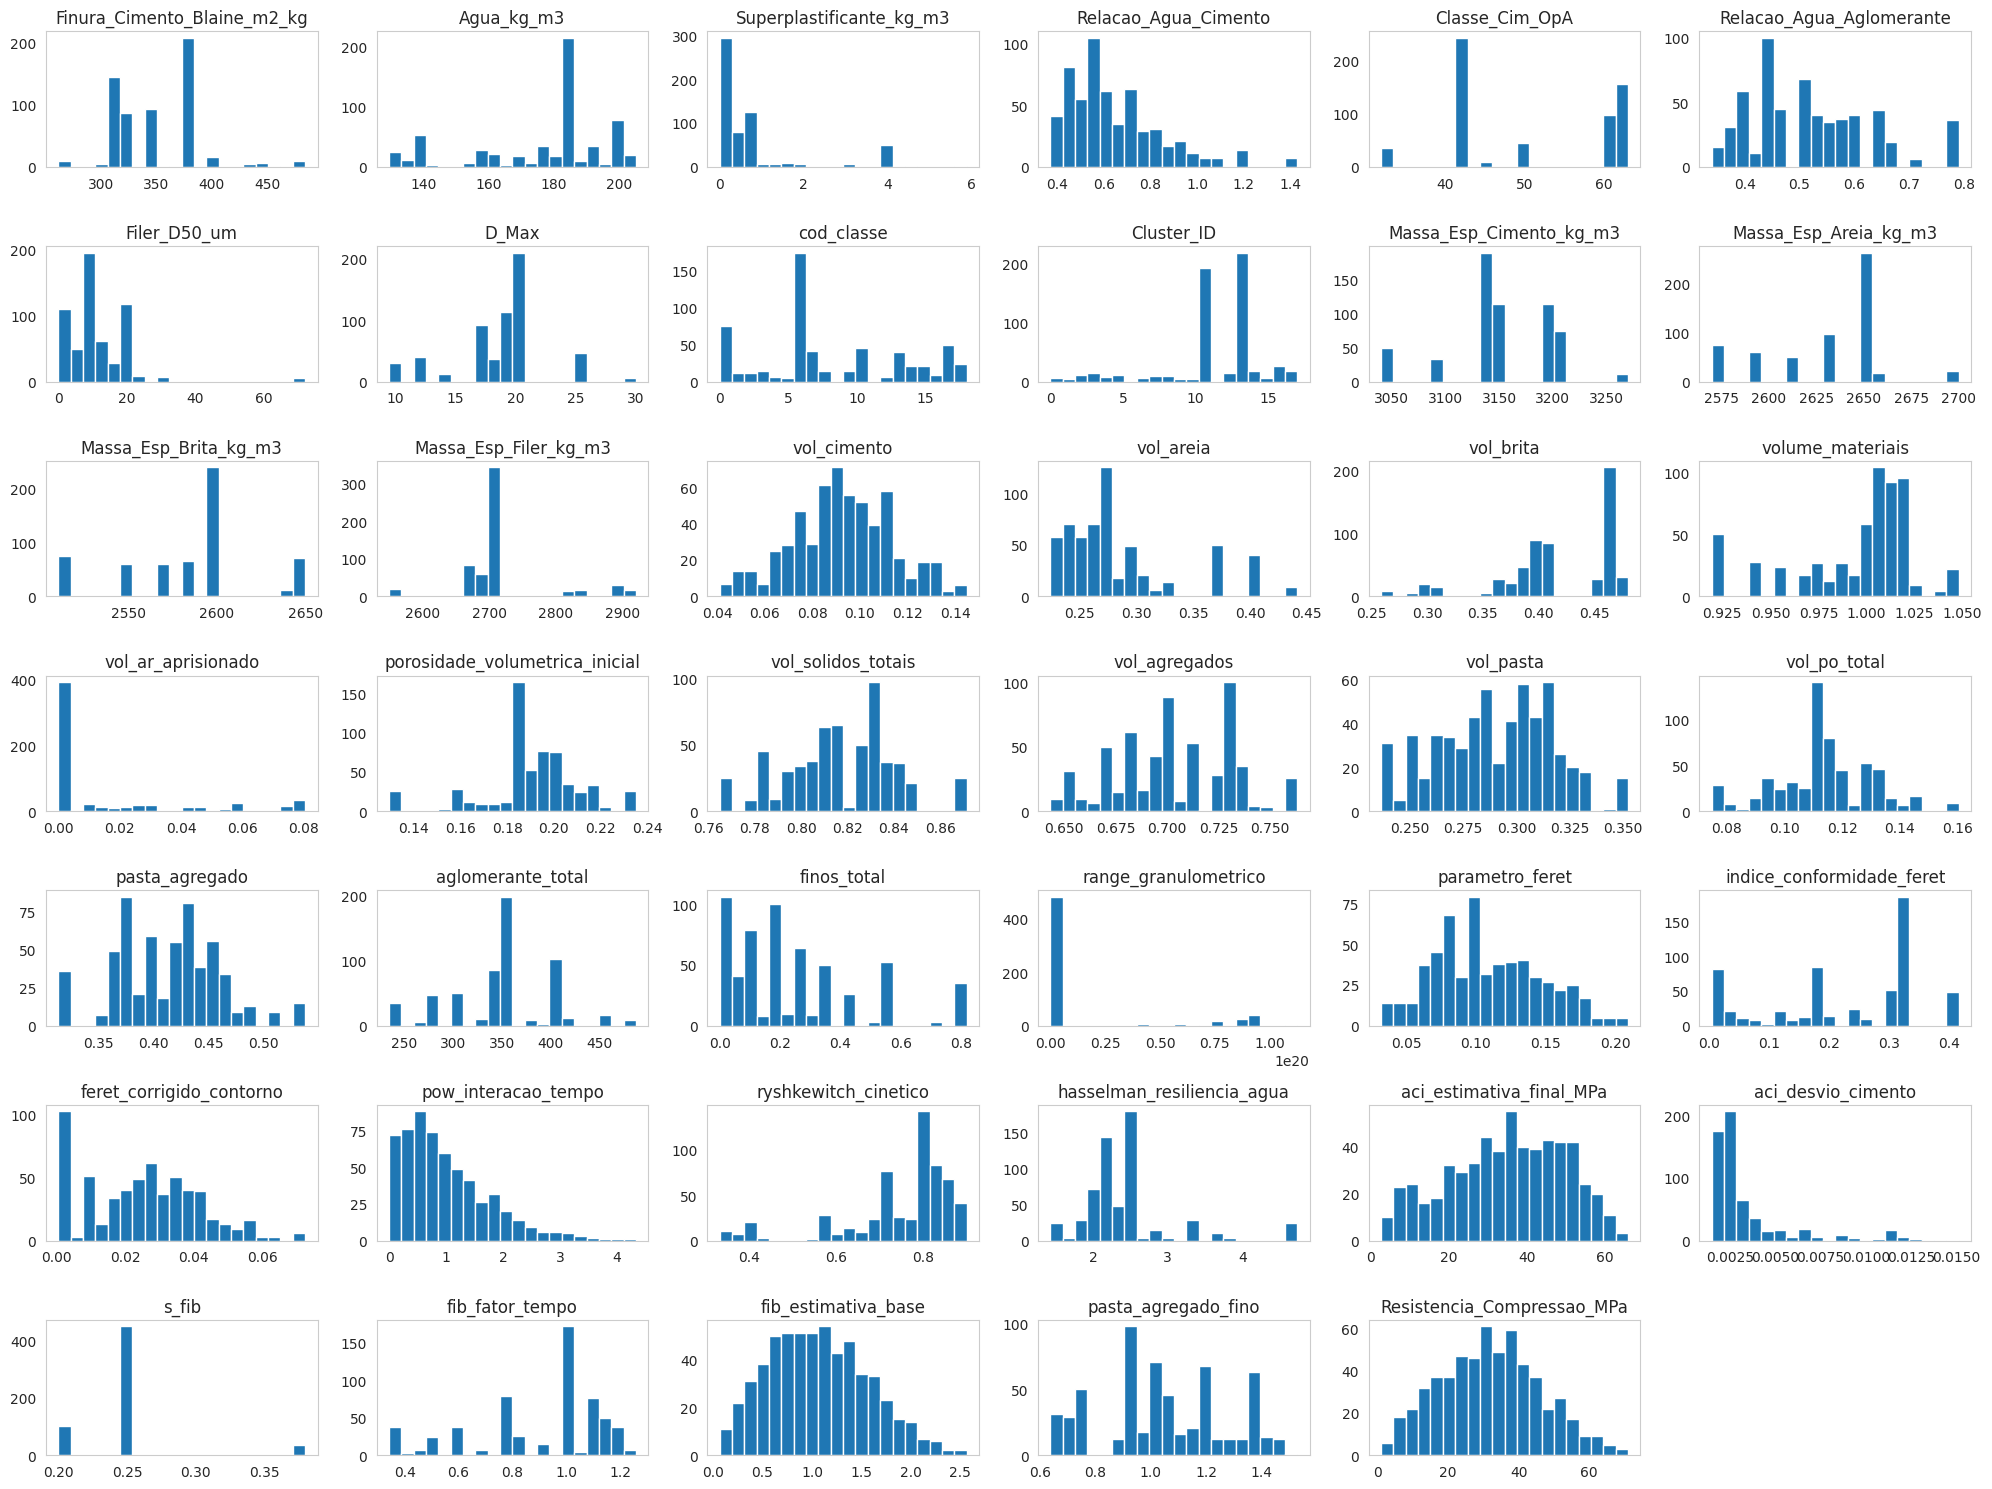

In [79]:
df_final.hist(bins=20, figsize=(20, 15), grid=False)
plt.tight_layout()
plt.show()

In [80]:
df_final.to_pickle(os.path.join(base_dir, f'df_resistencia_{nome_modelo}.pkl'))